In [27]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest
from src.finance import calculate_beta

## Correlation Analysis

In [28]:
assets = ['AAPL', 'MSFT','SPY', 'NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']

returns_df = pd.DataFrame()

for asset in assets:
    df = get_data(asset, "2016-01-01", "2026-01-01")
    df = generate_features(df)
    returns_df[asset] = df["returns"]

returns_df = returns_df.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [29]:
corr_matrix = returns_df.corr()


In [30]:
corr_matrix.to_csv("../outputs/correlation_matrix.csv")


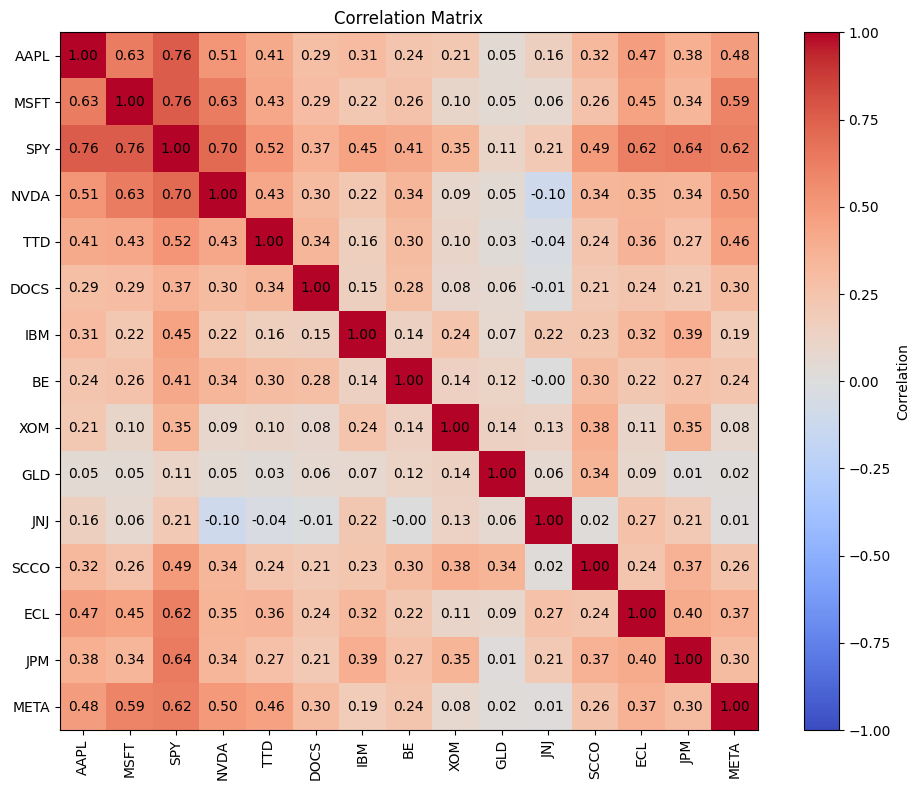

In [31]:
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

## Covariance Maatrix

In [32]:
cov_matrix = returns_df.cov()
cov_matrix

,AAPL,MSFT,SPY,NVDA,TTD,DOCS,IBM,BE,XOM,GLD,JNJ,SCCO,ECL,JPM,META
AAPL,0.000308,0.000181,0.000148,0.000300,0.000305,0.000220,0.000081,0.000218,0.000063,0.000009,0.000029,0.000132,0.000126,0.000104,0.000237
MSFT,0.000181,0.000269,0.000138,0.000346,0.000300,0.000209,0.000053,0.000223,0.000026,0.000009,0.000011,0.000101,0.000111,0.000087,0.000274
SPY,0.000148,0.000138,0.000121,0.000259,0.000244,0.000180,0.000074,0.000240,0.000063,0.000012,0.000024,0.000126,0.000104,0.000109,0.000193
NVDA,0.000300,0.000346,0.000259,0.001117,0.000608,0.000443,0.000108,0.000593,0.000052,0.000017,-0.000036,0.000265,0.000174,0.000176,0.000466
TTD,0.000305,0.000300,0.000244,0.000608,0.001812,0.000636,0.000103,0.000680,0.000073,0.000013,-0.000016,0.000237,0.000230,0.000181,0.000545
DOCS,0.000220,0.000209,0.000180,0.000443,0.000636,0.001911,0.000099,0.000649,0.000058,0.000025,-0.000005,0.000214,0.000157,0.000141,0.000370
IBM,0.000081,0.000053,0.000074,0.000108,0.000103,0.000099,0.000223,0.000107,0.000060,0.000011,0.000036,0.000080,0.000073,0.000090,0.000079
BE,0.000218,0.000223,0.000240,0.000593,0.000680,0.000649,0.000107,0.002764,0.000127,0.000064,-0.000001,0.000374,0.000174,0.000221,0.000354
XOM,0.000063,0.000026,0.000063,0.000052,0.000073,0.000058,0.000060,0.000127,0.000277,0.000023,0.000023,0.000148,0.000027,0.000090,0.000035
GLD,0.000009,0.000009,0.000012,0.000017,0.000013,0.000025,0.000011,0.000064,0.000023,0.000097,0.000006,0.000080,0.000013,0.000002,0.000006


In [33]:
cov_matrix.to_csv("../outputs/covariance_matrix.csv")

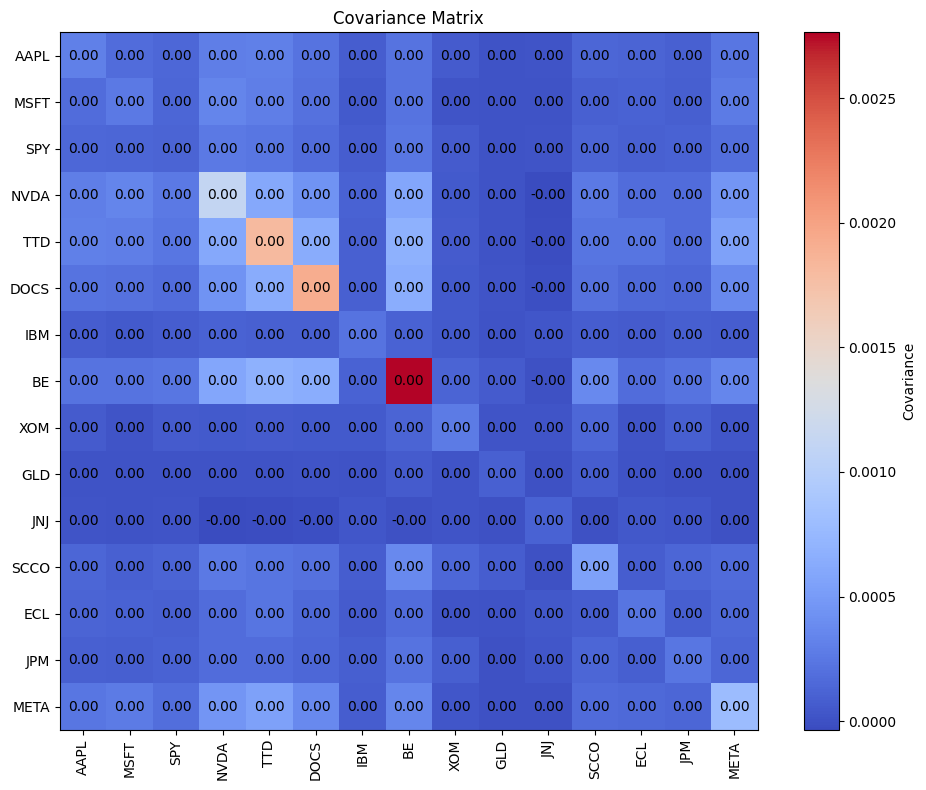

In [34]:
plt.figure(figsize=(10, 8))

plt.imshow(cov_matrix, cmap="coolwarm")

plt.colorbar(label="Covariance")

plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns, rotation=90)
plt.yticks(range(len(cov_matrix.index)), cov_matrix.index)

for i in range(len(cov_matrix)):
    for j in range(len(cov_matrix.columns)):
        plt.text(j, i, f"{cov_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Covariance Matrix")
plt.tight_layout()

plt.show()